<a href="https://colab.research.google.com/github/dlgkwls/semicon-analysis-1/blob/main/semiconductor_revenue_summary_2010_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Semiconductor Revenue Summary, 2010–2026

This notebook loads semiconductor company financial data, cleans the dataset, and creates three basic charts: a line chart, bar chart, and scatter plot.

The goal is to practice the same workflow used in engineering analysis:
load data, inspect quality, clean columns, and visualize trends clearly.

## 1. Import libraries

I import pandas for table operations, matplotlib/seaborn for visualization, and IPython display tools for adding chart captions below each figure.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

print("Set up Complete")

Set up Complete


## 2. Upload and load the CSV file

I load one CSV file using `pd.read_csv()` so the notebook starts from raw tabular data. For this first project, I use the company financials file because it contains yearly revenue, margins, R&D spend, and capex for many semiconductor companies.

In [2]:
url = "https://raw.githubusercontent.com/dlgkwls/semicon-analysis-1/refs/heads/main/chip_companies_financials.csv"
df = pd.read_csv(url)

df.head()

,year,company_name,ticker,country_iso3,segment,revenue_usd_bn,operating_margin_pct,operating_income_usd_bn,rd_spend_usd_bn,capex_usd_bn
0,2010,TSMC,TSM,TWN,foundry,13.42,36.9,4.95,1.07,6.04
1,2011,TSMC,TSM,TWN,foundry,16.32,42.8,6.99,1.31,7.35
2,2012,TSMC,TSM,TWN,foundry,17.56,36.1,6.34,1.40,7.90
3,2013,TSMC,TSM,TWN,foundry,21.36,39.1,8.34,1.71,9.61
4,2014,TSMC,TSM,TWN,foundry,23.93,37.4,8.96,1.91,10.77


## 3. Inspect the dataset

I check the shape, columns, data types, and missing values before cleaning. This helps confirm whether numeric columns are stored as numbers and whether any missing values need to be filled or removed.

In [3]:
print("Rows and columns:")
print(df.shape)

print("\nColumn names:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

print("\nMissing values by column:")
print(df.isnull().sum())

Rows and columns:
(617, 10)

Column names:
Index(['year', 'company_name', 'ticker', 'country_iso3', 'segment',
       'revenue_usd_bn', 'operating_margin_pct', 'operating_income_usd_bn',
       'rd_spend_usd_bn', 'capex_usd_bn'],
      dtype='object')

Data types:
year                         int64
company_name                object
ticker                      object
country_iso3                object
segment                     object
revenue_usd_bn             float64
operating_margin_pct       float64
operating_income_usd_bn    float64
rd_spend_usd_bn            float64
capex_usd_bn               float64
dtype: object

Missing values by column:
year                       0
company_name               0
ticker                     0
country_iso3               0
segment                    0
revenue_usd_bn             0
operating_margin_pct       0
operating_income_usd_bn    0
rd_spend_usd_bn            0
capex_usd_bn               0
dtype: int64


## 4. Clean the dataset

I make a clean copy of the dataset, fix the year column as an integer, clean text columns, and median-fill numeric missing values. Median filling is useful for financial and sensor-style data because the median is less affected by unusually large spikes than the mean.

In [4]:
clean_df = df.copy()

# Fix expected data types
clean_df["year"] = clean_df["year"].astype(int)

# Clean text columns
text_cols = ["company_name", "ticker", "country_iso3", "segment"]

for col in text_cols:
  clean_df[col] = clean_df[col].astype(str).str.strip()

"""OR
text_cols = clean_df.select_dtypes(include="object").columns

for col in text_cols:
    clean_df[col] = clean_df[col].astype(str).str.strip()"""

# Median-fill numeric columns
numeric_cols = clean_df.select_dtypes(include = "number").columns

for col in numeric_cols:
  clean_df[col] = clean_df[col].fillna(clean_df[col].median())

# Drop duplicate rows, if any
removed = clean_df.duplicated().sum()
clean_df = clean_df.drop_duplicates()
print("Duplicate rows removed:", removed)

print("\nCleaned shape:")
print(clean_df.shape)

print("\nRemaining missing values:")
print(clean_df.isnull().sum())

Duplicate rows removed: 0

Cleaned shape:
(617, 10)

Remaining missing values:
year                       0
company_name               0
ticker                     0
country_iso3               0
segment                    0
revenue_usd_bn             0
operating_margin_pct       0
operating_income_usd_bn    0
rd_spend_usd_bn            0
capex_usd_bn               0
dtype: int64


## 5. Create a focused NVIDIA dataframe

I filter the cleaned dataset to NVIDIA only and sort the rows by year. This prepares the data for a time-series line chart showing how NVIDIA revenue changed from 2010 to 2026.

In [5]:
nvidia = clean_df[clean_df["company_name"] == "NVIDIA"].copy()

nvidia = nvidia.sort_values("year")

nvidia.head()

,year,company_name,ticker,country_iso3,segment,revenue_usd_bn,operating_margin_pct,operating_income_usd_bn,rd_spend_usd_bn,capex_usd_bn
85,2010,NVIDIA,NVDA,USA,fabless_gpu,3.43,56.3,1.93,0.86,0.07
86,2011,NVIDIA,NVDA,USA,fabless_gpu,3.75,51.3,1.92,0.94,0.07
87,2012,NVIDIA,NVDA,USA,fabless_gpu,3.95,55.5,2.19,0.99,0.08
88,2013,NVIDIA,NVDA,USA,fabless_gpu,4.61,55.5,2.56,1.15,0.09
89,2014,NVIDIA,NVDA,USA,fabless_gpu,4.68,55.9,2.62,1.17,0.09


## 6. Line chart: NVIDIA revenue over time

I use a line chart because revenue is measured across years. A line chart makes the long-term growth trend easier to see than a table.

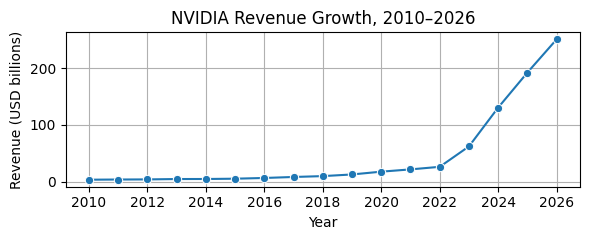

**Caption:** NVIDIA revenue increased sharply in the AI accelerator era, making it a useful case study for semiconductor growth analysis.

In [6]:
plt.figure(figsize=(6,2.5))

sns.lineplot(
    data=nvidia,
    x = "year",
    y = "revenue_usd_bn",
    marker = "o"
)

plt.title("NVIDIA Revenue Growth, 2010–2026")
plt.xlabel("Year")
plt.ylabel("Revenue (USD billions)")
plt.grid(True)
plt.tight_layout()
plt.show()

display(Markdown(
    "**Caption:** NVIDIA revenue increased sharply in the AI accelerator era, making it a useful case study for semiconductor growth analysis."
))

## 7. Prepare segment revenue data for 2024

I group companies by semiconductor segment and sum their 2024 revenue. This turns company-level rows into a segment-level summary for comparison.

In [29]:
segment_2024 = clean_df[clean_df["year"] == 2024].copy()

segment_revenue_2024 = (
    segment_2024.groupby("segment")["revenue_usd_bn"].sum().sort_values(ascending = False).head(20)
)

segment_revenue_2024.values
#help(plt.text)

array([160.97, 131.07, 130.48,  63.46,  56.2 ,  54.42,  40.95,  37.61,
        31.81,  26.05,  24.36,  14.85,  12.72,  10.38,   9.96,   6.87,
         5.84,   4.27,   4.26,   1.98])

## 8. Bar chart: 2024 revenue by semiconductor segment

I use a bar chart because it compares categories. Here, each bar represents one semiconductor business segment, and the height shows total revenue.

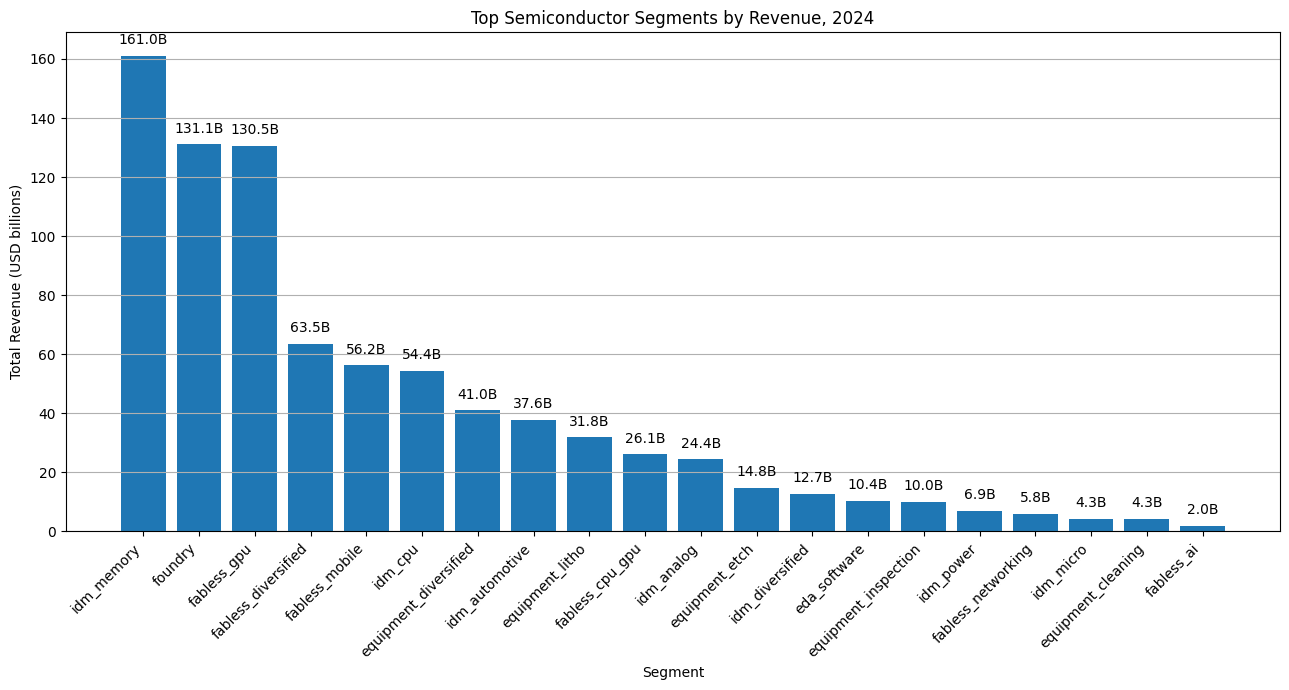

**Caption:** The largest semiconductor segments in 2024 show where industry revenue was concentrated across business models such as foundry, memory, fabless, and equipment.

In [45]:
plt.figure(figsize = (13,7))

plt.bar(
    segment_revenue_2024.index,
    segment_revenue_2024.values
)

for i, value in enumerate(segment_revenue_2024.values):
    plt.text(
        i,
        value + 3,
        f"{value:.1f}B",
        ha="center",
        va="bottom")

plt.title("Top Semiconductor Segments by Revenue, 2024")
plt.xlabel("Segment")
plt.ylabel("Total Revenue (USD billions)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

display(Markdown(
    "**Caption:** The largest semiconductor segments in 2024 show where industry revenue was concentrated across business models such as foundry, memory, fabless, and equipment."
))

## 9. Prepare 2024 R&D and revenue data

I use 2024 company-level data to compare R&D spending with revenue. This checks whether larger semiconductor companies also tend to spend more on research and development.

In [50]:
scatter_2024 = clean_df[clean_df["year"] == 2024].copy()

scatter_2024 = scatter_2024[
    ["company_name", "segment", "revenue_usd_bn", "rd_spend_usd_bn"]
]

scatter_2024[scatter_2024["revenue_usd_bn"] > 25 ]

,company_name,segment,revenue_usd_bn,rd_spend_usd_bn
14,TSMC,foundry,88.89,7.11
99,NVIDIA,fabless_gpu,130.48,32.62
116,AMD,fabless_cpu_gpu,26.05,5.21
133,Qualcomm,fabless_mobile,39.18,4.70
150,Broadcom,fabless_diversified,54.34,6.52
201,Intel,idm_cpu,54.42,10.88
218,Samsung Memory,idm_memory,74.79,7.48
235,SK Hynix,idm_memory,51.53,5.15
405,ASML,equipment_litho,31.81,5.09
422,Applied Materials,equipment_diversified,27.31,3.28


## 10. Scatter plot: R&D spend vs revenue

I use a scatter plot because it shows the relationship between two numeric variables. Each point represents one company, with revenue on the x-axis and R&D spend on the y-axis.

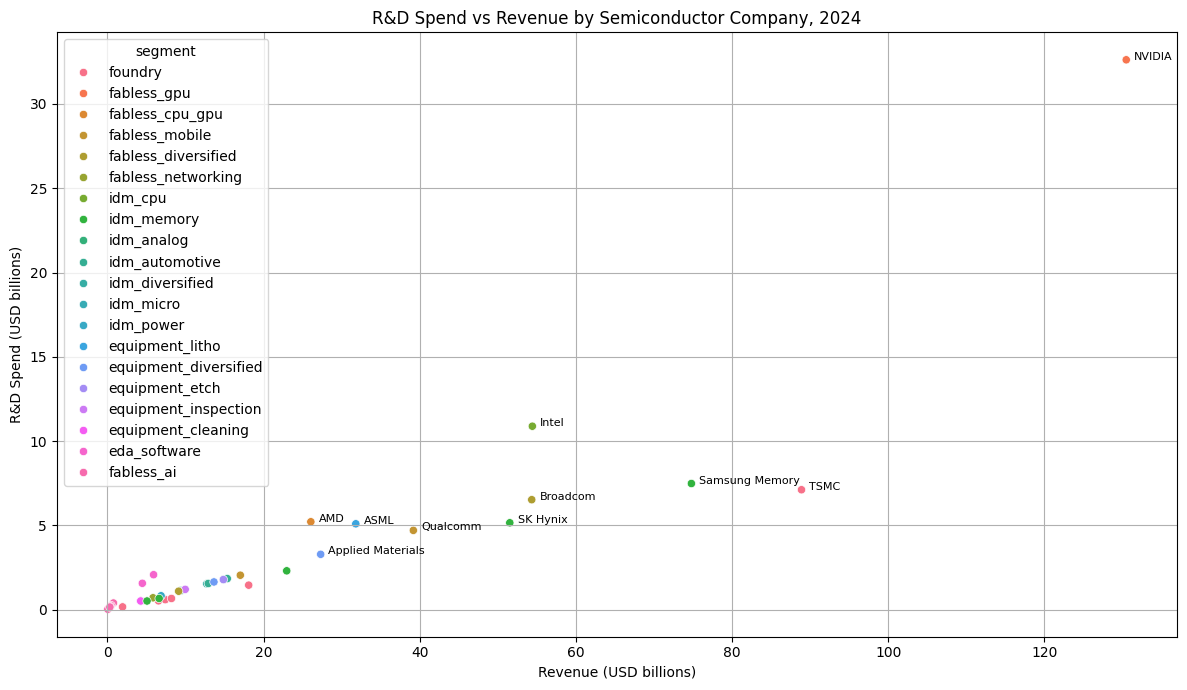

**Caption:** Companies with higher revenue generally have more room to fund R&D, but the spread also reflects different business models across the semiconductor industry.

In [53]:
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=scatter_2024,
    x="revenue_usd_bn",
    y="rd_spend_usd_bn",
    hue="segment"
)

for _, row in scatter_2024.iterrows():
  if row["revenue_usd_bn"] > 25:
    plt.text(
        row["revenue_usd_bn"] + 1,
        row["rd_spend_usd_bn"],
        row["company_name"],
        fontsize=8
    )

plt.title("R&D Spend vs Revenue by Semiconductor Company, 2024")
plt.xlabel("Revenue (USD billions)")
plt.ylabel("R&D Spend (USD billions)")
plt.grid(True)
plt.tight_layout()
plt.show()

display(Markdown(
    "**Caption:** Companies with higher revenue generally have more room to fund R&D, but the spread also reflects different business models across the semiconductor industry."
))

## 11. Final observations

This notebook shows a basic semiconductor data-analysis workflow:

1. Loaded a CSV file with `pd.read_csv()`.
2. Inspected rows, columns, data types, and missing values.
3. Cleaned text fields, fixed data types, median-filled numeric columns, and dropped duplicates.
4. Built three labelled charts:
   - Line chart for NVIDIA revenue over time.
   - Bar chart for 2024 revenue by segment.
   - Scatter plot for R&D spend vs revenue.

The main takeaway is that semiconductor analysis becomes easier when the question is narrowed before plotting. Here, NVIDIA growth, segment revenue concentration, and R&D intensity each answer a different business question.